In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
data = (
    pd.read_csv(
        'acral_full_1000g_qc_prune_at_cg_k5_labels.csv',
        sep=',')
    .assign(SUPERPOP=lambda df: df['SUPERPOP'].mask(df['SUPERPOP'] == '-', 'ALM'))
)
data.columns = ['FID', 'SUPERPOP', 'pop1', 'pop2', 'pop3', 'pop4', 'pop5']

In [3]:
patients = [
    "PD40952a","PD40956d","PD40957a","PD40961a","PD40962a","PD40963a","PD40964a",
    "PD40965a","PD40966a","PD40967a","PD40968a","PD40969a","PD40970a","PD40971a",
    "PD40972a","PD40973a","PD40974a","PD40976a","PD40978a","PD40980a","PD40982a",
    "PD40983a","PD40984a","PD40985a","PD40986a","PD40987a","PD40988a","PD40989a",
    "PD40990a","PD40994a","PD40996a","PD40997a","PD41000a","PD41001a","PD41002a",
    "PD41004a","PD41011a","PD41017a","PD41020a","PD41021d","PD41023f","PD41025a",
    "PD41026d","PD41027a","PD41029e","PD41030a","PD41032a","PD41033a","PD41035a",
    "PD41036a","PD41038a","PD41039d","PD41043a","PD41044a","PD41045a","PD41046a",
    "PD41895a","PD41896a","PD41900a","PD41901a","PD41905a","PD41906a","PD41907a",
    "PD41909a","PD41910a","PD41912a","PD41913a","PD41915c","PD41916a","PD41920a",
    "PD41921a","PD41923g","PD41927d","PD41928d","PD41930d","PD41932d","PD41939d",
    "PD51928a","PD51929a","PD51930a","PD51932a","PD51939a","PD51940d","PD51948a",
    "PD51951a","PD51952a","PD51969a","PD51972a","PD51978a","PD51979a","PD51982a",
    "PD51993a"
]

In [21]:
(
    pd.read_csv('acral_full_1000g_qc_prune_at_cg.5.Q', sep=' ', header=None, names=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    .assign(ID=data.FID,SUPERPOP=data.SUPERPOP)
    .groupby('SUPERPOP')
    [['Q1', 'Q2', 'Q3', 'Q4', 'Q5']]
    .mean()
    .style.format(precision=2)
)

,Q1,Q2,Q3,Q4,Q5
SUPERPOP,,,,,
AFR,0.95,0.00,0.00,0.00,0.04
ALM,0.04,0.71,0.00,0.00,0.24
AMR,0.07,0.41,0.00,0.00,0.51
EAS,0.00,0.00,0.00,1.00,0.00
EUR,0.00,0.00,0.00,0.01,0.98
SAS,0.00,0.00,0.91,0.02,0.06


In [ ]:
pops_unsup = {
    'Q5': 'EUR',
    'Q4': 'EAS',
    'Q2': '--',
    'Q3': 'SAS',
    'Q1': 'AFR'
}

(
    pd.read_csv('acral_full_1000g_qc_prune_at_cg.5.Q', sep=' ', header=None, names=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    .assign(ID=data.FID,SUPERPOP=data.SUPERPOP)
    [['ID', 'SUPERPOP', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5']]
    #.to_csv('acral_full_1000g_qc_prune_at_cg_k5_labels.csv', index=False)
)

,ID,SUPERPOP,Q1,Q2,Q3,Q4,Q5
0,PD40952c,ALM,0.000010,0.999960,0.000010,0.000010,0.000010
1,PD40953c,ALM,0.023546,0.775192,0.000010,0.000010,0.201242
2,PD51995c,ALM,0.000010,0.924801,0.002010,0.004622,0.068556
3,PD40954c,ALM,0.014120,0.794402,0.000010,0.000010,0.191457
4,PD51947b,ALM,0.026284,0.079001,0.000010,0.000010,0.894695
...,...,...,...,...,...,...,...
2699,NA21137,SAS,0.000010,0.000010,0.947554,0.000010,0.052416
2700,NA21141,SAS,0.000010,0.000010,0.948549,0.000010,0.051421
2701,NA21142,SAS,0.000010,0.000010,0.946114,0.000010,0.053856
2702,NA21143,SAS,0.000010,0.000010,0.959355,0.000010,0.040615


In [8]:
#(
#    data
#    .groupby('SUPERPOP')
#    [['P1', 'P2', 'P3', 'P4', 'P5']]
#    .mean()
#)
#pops = {
#    'P1': 'EUR',
#    'P2': 'EAS',
#    'P3': 'AMR',
#    'P4': 'SAS',
#    'P5': 'AFR'
#}
#data = data.rename(columns=pops)

In [10]:
seq_patients = [x[:-1] for x in patients]

data_plot = (
    data
    .assign(id_patient=lambda x: x.FID.mask(x.FID.str.contains('PD'), x.FID.str[0:7]))
    .query('id_patient.isin(@seq_patients) | (SUPERPOP != "ALM")')
    .drop_duplicates('id_patient')
)

In [11]:
len(seq_patients)

92

In [12]:
data_plot.query('SUPERPOP=="ALM"').FID.apply(lambda x: x[0:7]).unique().shape

(80,)

In [13]:
data_plot.FID.to_clipboard(index=False)

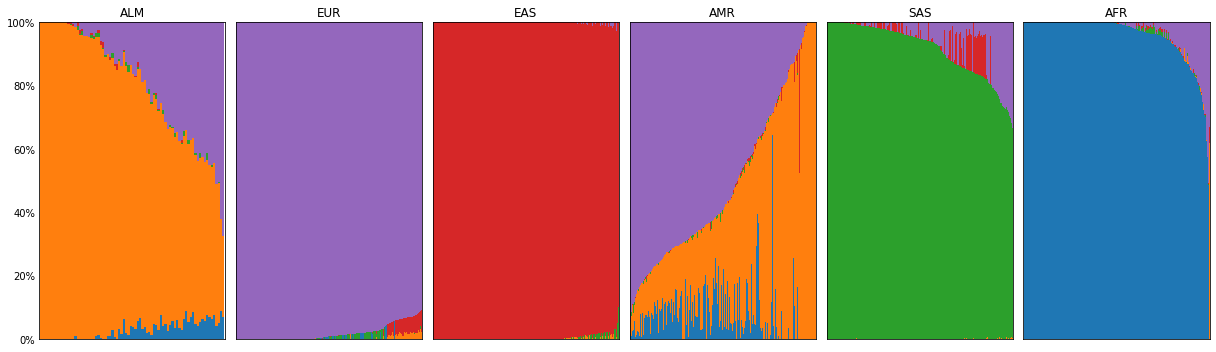

In [14]:
fig, axes = plt.subplots(1,6,figsize=(17,5),sharey=True,tight_layout=True)

for i, sp in enumerate(data.SUPERPOP.unique()):
    adm_sp = (
        data_plot
        .query('SUPERPOP == @sp')
        .rename(columns = 
            {'P1': 'pop1', 'P2': 'pop2', 'P3': 'pop3', 'P4': 'pop4', 'P5': 'pop5'})
    )
    main_pop = adm_sp[adm_sp.columns[adm_sp.columns.str.startswith('pop')]].mean().idxmax()
    (
        adm_sp
        .sort_values(main_pop,ascending=False)
        [adm_sp.columns[adm_sp.columns.str.startswith('pop')]]
        .plot(kind='bar',stacked=True,width=1,ax=axes[i],
              sharey=True,title=sp,legend=False,ylim=(0,1), antialiased=True,rasterized=True)
    )
    axes[i].set_xticklabels([])
    axes[i].tick_params(axis='both', which='both', length=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# save as pdf
plt.savefig('admixture_raster.pdf',bbox_inches='tight')